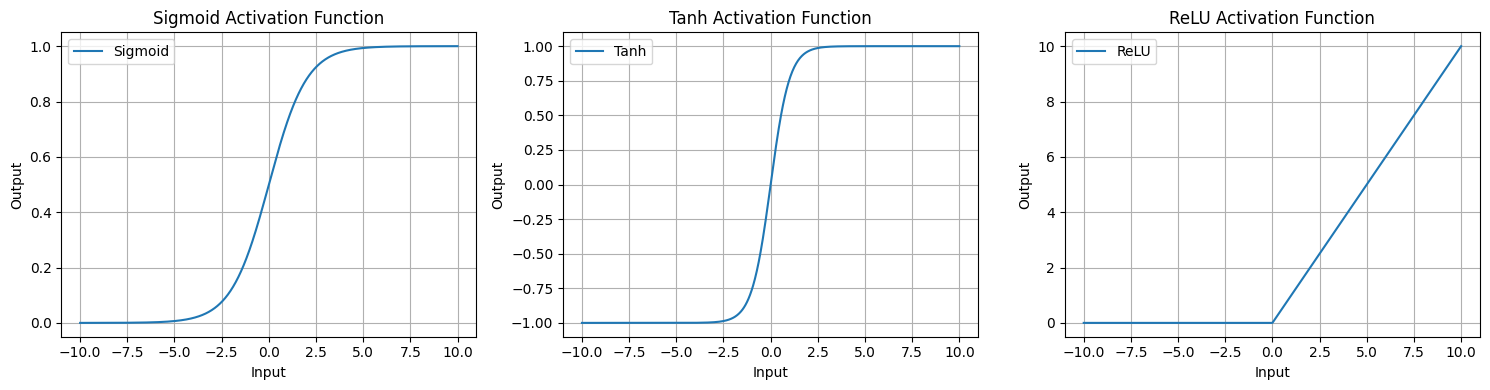

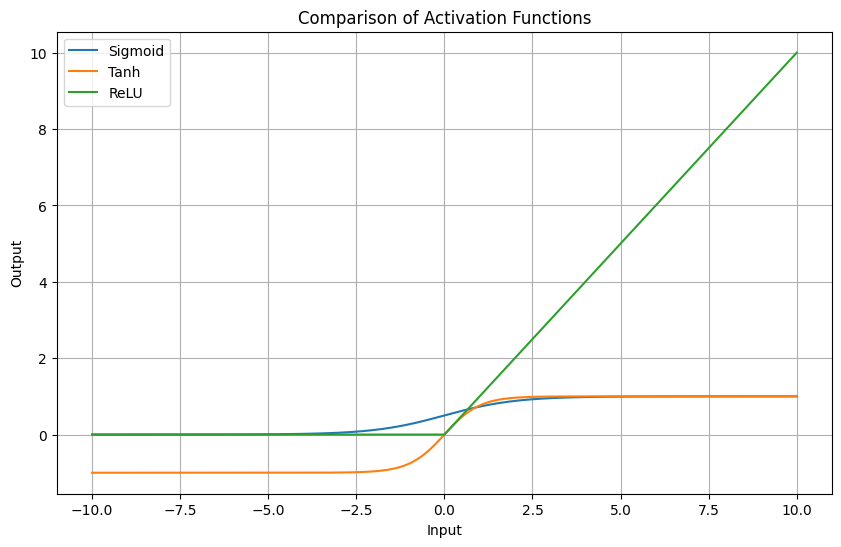

In [ ]:
# ============================================================
# Name     : Mohd Shafique R B
# Roll No  : 24BAD074
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# Input values
x = np.linspace(-10, 10, 1000)

# Activation Functions
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def tanh(x):
    return np.tanh(x)

def relu(x):
    return np.maximum(0, x)

# Calculate activation values
sigmoid_y = sigmoid(x)
tanh_y = tanh(x)
relu_y = relu(x)

# Plotting Activation Functions
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.plot(x, sigmoid_y, label="Sigmoid")
plt.title("Sigmoid Activation Function")
plt.xlabel("Input")
plt.ylabel("Output")
plt.grid(True)
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(x, tanh_y, label="Tanh")
plt.title("Tanh Activation Function")
plt.xlabel("Input")
plt.ylabel("Output")
plt.grid(True)
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(x, relu_y, label="ReLU")
plt.title("ReLU Activation Function")
plt.xlabel("Input")
plt.ylabel("Output")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

# Combined Comparison Plot
plt.figure(figsize=(10, 6))

plt.plot(x, sigmoid_y, label="Sigmoid")
plt.plot(x, tanh_y, label="Tanh")
plt.plot(x, relu_y, label="ReLU")

plt.title("Comparison of Activation Functions")
plt.xlabel("Input")
plt.ylabel("Output")
plt.grid(True)
plt.legend()

plt.show()


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Training model using: SIGMOID
Epoch 1/10


/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8131 - loss: 0.8155 - val_accuracy: 0.9161 - val_loss: 0.3188
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9247 - loss: 0.2692 - val_accuracy: 0.9366 - val_loss: 0.2159
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9429 - loss: 0.1989 - val_accuracy: 0.9480 - val_loss: 0.1746
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9539 - loss: 0.1593 - val_accuracy: 0.9547 - val_loss: 0.1493
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9614 - loss: 0.1319 - val_accuracy: 0.9627 - val_loss: 0.1266
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9683 - loss: 0.1103 - val_accuracy: 0.9649 - val_loss: 0.1171
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9733 - loss: 0.0944 - val_accuracy: 0.9686 - val_loss: 0.1018
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9775 - loss: 0.0805 - val_accuracy: 0.9721 - val_

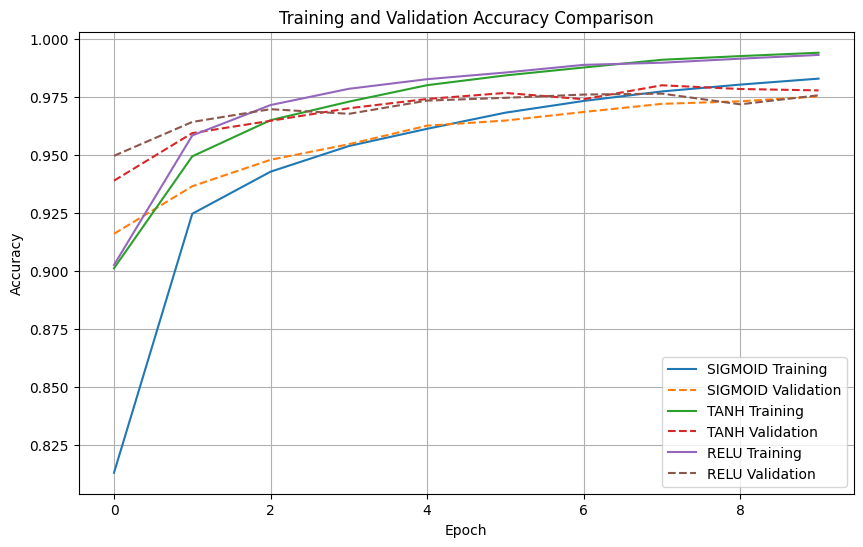

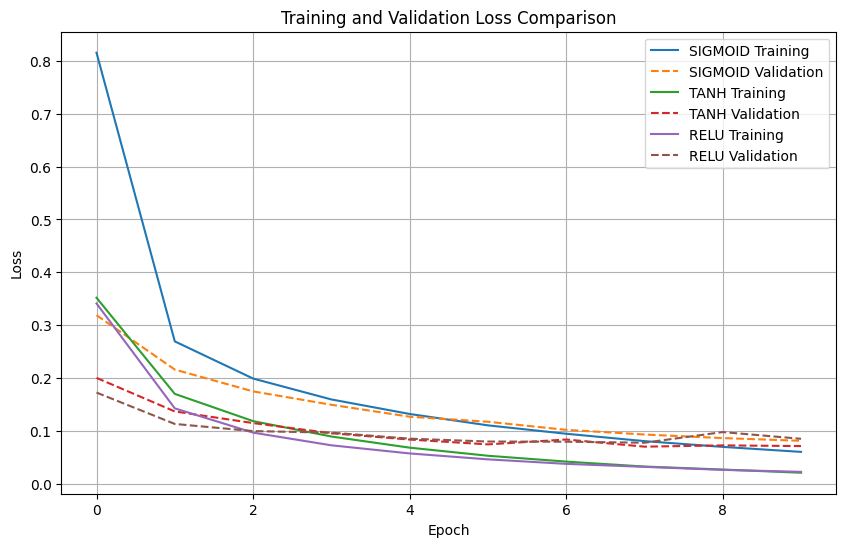


BEST ACTIVATION FUNCTION
Activation Function: TANH
Validation Accuracy: 97.79 %


In [ ]:
# ============================================================
# TASK B: PERFORMANCE COMPARISON OF ACTIVATION FUNCTIONS
# Name     : Mohd Shafique R B
# Roll No  : 24BAD074
# ============================================================

import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize the dataset
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Build ANN model
def create_model(activation):
    model = tf.keras.Sequential([
        tf.keras.layers.Flatten(input_shape=(28, 28)),
        tf.keras.layers.Dense(128, activation=activation),
        tf.keras.layers.Dense(64, activation=activation),
        tf.keras.layers.Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

# Activation functions to compare
activations = ["sigmoid", "tanh", "relu"]

# Store training histories
histories = {}

# Store comparison results
results = []

# Train models
for activation in activations:

    print("\nTraining model using:", activation.upper())

    model = create_model(activation)

    history = model.fit(
        x_train,
        y_train,
        validation_data=(x_test, y_test),
        epochs=10,
        batch_size=128,
        verbose=1
    )

    histories[activation] = history

    train_accuracy = history.history["accuracy"][-1]
    val_accuracy = history.history["val_accuracy"][-1]
    train_loss = history.history["loss"][-1]
    val_loss = history.history["val_loss"][-1]

    # Calculate convergence epoch
    best_accuracy = max(history.history["val_accuracy"])
    convergence_epoch = history.history["val_accuracy"].index(best_accuracy) + 1

    results.append([
        activation.upper(),
        train_accuracy,
        val_accuracy,
        train_loss,
        val_loss,
        convergence_epoch
    ])

# Create comparison table
comparison = pd.DataFrame(
    results,
    columns=[
        "Activation Function",
        "Training Accuracy",
        "Validation Accuracy",
        "Training Loss",
        "Validation Loss",
        "Epoch of Best Validation Accuracy"
    ]
)

print("\nACTIVATION FUNCTION PERFORMANCE COMPARISON")
print(comparison.to_string(index=False))

# Accuracy Comparison
plt.figure(figsize=(10, 6))

for activation in activations:
    plt.plot(
        histories[activation].history["accuracy"],
        label=activation.upper() + " Training"
    )
    plt.plot(
        histories[activation].history["val_accuracy"],
        linestyle="--",
        label=activation.upper() + " Validation"
    )

plt.title("Training and Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Loss Comparison
plt.figure(figsize=(10, 6))

for activation in activations:
    plt.plot(
        histories[activation].history["loss"],
        label=activation.upper() + " Training"
    )
    plt.plot(
        histories[activation].history["val_loss"],
        linestyle="--",
        label=activation.upper() + " Validation"
    )

plt.title("Training and Validation Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# Identify best activation function
best_model = comparison.loc[
    comparison["Validation Accuracy"].idxmax()
]

print("\nBEST ACTIVATION FUNCTION")
print("Activation Function:", best_model["Activation Function"])
print("Validation Accuracy:", round(best_model["Validation Accuracy"] * 100, 2), "%")


Training model using: SGD
Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6808 - loss: 1.2976 - val_accuracy: 0.8596 - val_loss: 0.6020
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8739 - loss: 0.4963 - val_accuracy: 0.8945 - val_loss: 0.3967
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8961 - loss: 0.3810 - val_accuracy: 0.9049 - val_loss: 0.3380
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9064 - loss: 0.3353 - val_accuracy: 0.9132 - val_loss: 0.3073
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9129 - loss: 0.3079 - val_accuracy: 0.9202 - val_loss: 0.2847
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9183 - loss: 0.2884 - val_accuracy: 0.9253 - val_loss: 0.2698
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9228 - loss: 0.2725 - val_accuracy: 0.9271 - val_loss: 0.2572
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9265 - loss

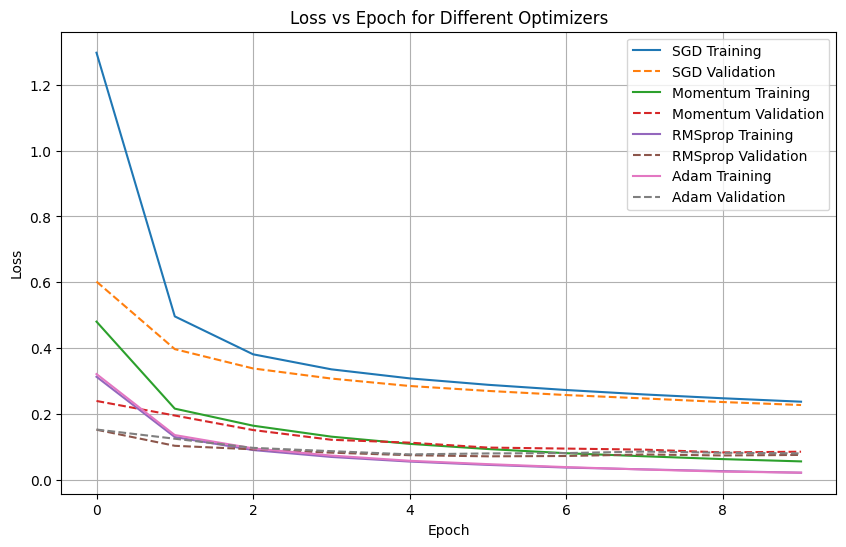

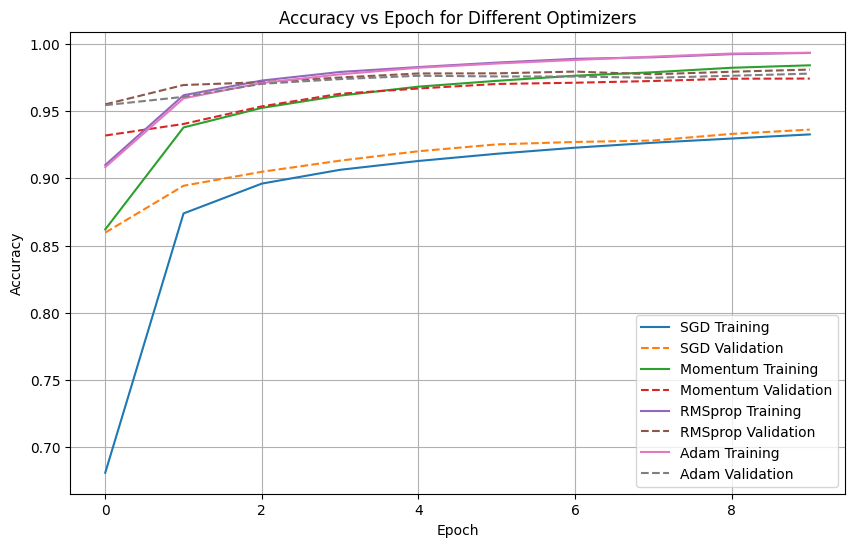


BEST OPTIMIZER
Optimizer: RMSprop
Validation Accuracy: 98.1 %
Best Accuracy Achieved at Epoch: 10


In [ ]:
# ============================================================
# TASK C: COMPARISON OF OPTIMIZATION ALGORITHMS
# Name     : Mohd Shafique R B
# Roll No  : 24BAD074
# ============================================================

import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize the dataset
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Build ANN model
def create_model(optimizer):
    model = tf.keras.Sequential([
        tf.keras.layers.Flatten(input_shape=(28, 28)),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

# Optimizers to compare
optimizers = {
    "SGD": tf.keras.optimizers.SGD(learning_rate=0.01),

    "Momentum": tf.keras.optimizers.SGD(
        learning_rate=0.01,
        momentum=0.9
    ),

    "RMSprop": tf.keras.optimizers.RMSprop(
        learning_rate=0.001
    ),

    "Adam": tf.keras.optimizers.Adam(
        learning_rate=0.001
    )
}

# Store histories and results
histories = {}
results = []

# Train models using different optimizers
for name, optimizer in optimizers.items():

    print("\nTraining model using:", name)

    model = create_model(optimizer)

    history = model.fit(
        x_train,
        y_train,
        validation_data=(x_test, y_test),
        epochs=10,
        batch_size=128,
        verbose=1
    )

    histories[name] = history

    train_accuracy = history.history["accuracy"][-1]
    val_accuracy = history.history["val_accuracy"][-1]
    train_loss = history.history["loss"][-1]
    val_loss = history.history["val_loss"][-1]

    # Find epoch with best validation accuracy
    best_accuracy = max(history.history["val_accuracy"])
    convergence_epoch = history.history["val_accuracy"].index(
        best_accuracy
    ) + 1

    results.append([
        name,
        train_loss,
        val_loss,
        train_accuracy,
        val_accuracy,
        convergence_epoch
    ])

# Create comparison table
comparison = pd.DataFrame(
    results,
    columns=[
        "Optimizer",
        "Training Loss",
        "Validation Loss",
        "Training Accuracy",
        "Validation Accuracy",
        "Best Accuracy Epoch"
    ]
)

print("\nOPTIMIZER PERFORMANCE COMPARISON")
print(comparison.to_string(index=False))

# Loss vs Epoch
plt.figure(figsize=(10, 6))

for name in optimizers.keys():
    plt.plot(
        histories[name].history["loss"],
        label=name + " Training"
    )

    plt.plot(
        histories[name].history["val_loss"],
        linestyle="--",
        label=name + " Validation"
    )

plt.title("Loss vs Epoch for Different Optimizers")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# Accuracy vs Epoch
plt.figure(figsize=(10, 6))

for name in optimizers.keys():
    plt.plot(
        histories[name].history["accuracy"],
        label=name + " Training"
    )

    plt.plot(
        histories[name].history["val_accuracy"],
        linestyle="--",
        label=name + " Validation"
    )

plt.title("Accuracy vs Epoch for Different Optimizers")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Identify the optimizer with best validation accuracy
best_optimizer = comparison.loc[
    comparison["Validation Accuracy"].idxmax()
]

print("\nBEST OPTIMIZER")
print("Optimizer:", best_optimizer["Optimizer"])
print(
    "Validation Accuracy:",
    round(best_optimizer["Validation Accuracy"] * 100, 2),
    "%"
)
print(
    "Best Accuracy Achieved at Epoch:",
    int(best_optimizer["Best Accuracy Epoch"])
)

In [7]:
# ============================================================
# TASK D: DEEP LEARNING EXPERIMENT MANAGEMENT
# Name     : Mohd Shafique R B
# Roll No  : 24BAD074
# ============================================================

from google.colab import drive

drive.mount('/content/drive')
# Create experiment folder
import os

folder_path = "/content/drive/MyDrive/Deep_Learning_Experiment"
os.makedirs(folder_path, exist_ok=True)

print("Experiment folder created successfully")
print("Folder location:", folder_path)

# Train and save ANN model

import tensorflow as tf

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize data
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Create ANN model
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

# Compile model
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Train model
model.fit(
    x_train,
    y_train,
    epochs=5,
    validation_data=(x_test, y_test)
)

# Save model to Google Drive
model_path = folder_path + "/mnist_ann_model.keras"
model.save(model_path)

print("\nModel trained successfully")
print("Model saved successfully")
print("Model location:", model_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Experiment folder created successfully
Folder location: /content/drive/MyDrive/Deep_Learning_Experiment
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.9306 - loss: 0.2379 - val_accuracy: 0.9622 - val_loss: 0.1265
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9690 - loss: 0.1017 - val_accuracy: 0.9685 - val_loss: 0.0997
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9783 - loss: 0.0707 - val_accuracy: 0.9739 - val_loss: 0.0902
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9826 - loss: 0.0551 - val_accuracy: 0.9775 - val_loss: 0.0778
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9860 - loss: 0.0435 - val_accuracy: 0.9775 - val_loss: 0.0806

Model trained successfully
Model saved successfully
Model location: /content/drive/MyDrive/Deep_Learning_Experiment/mnist_ann_model.keras


In [8]:
# Verify saved model

import os

print("Files in experiment folder:")
print(os.listdir(folder_path))

Files in experiment folder:
['mnist_ann_model.keras']
